In [37]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [38]:
docs = PyPDFLoader("../islr.pdf").load()

In [39]:
len(docs)

441

In [40]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [41]:
len(chunks)

1429

In [42]:
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [43]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [44]:
from langchain_groq import ChatGroq

In [45]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [ ]:
class State(TypedDict):
    question : str
    documents : List[Document]
    answer : str

In [47]:
def retrieve(state):
    q = state["question"]
    return {"documents": retriever.invoke(q)}

In [48]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

chain = prompt | llm

def generate(state:State):
    context = "/n/n".join(d.page_content for d in state['documents'])
    out = chain.invoke({'question': state['question'], 'context':context})
    return {'answer':out.content}

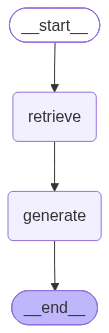

In [49]:
g = StateGraph(State)

g.add_node("retrieve", retrieve)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [50]:
res = app.invoke({'question':'What is linear regression?', "documents": []}) #type:ignore

In [56]:
import textwrap

out = textwrap.fill(res['answer'], width=80)
print(out)

Linear regression is a simple supervised‑learning method used to predict a
quantitative response \(Y\) from one or more predictor variables. In its basic
(simple) form it assumes that the relationship between a single predictor \(X\)
and the response is approximately linear and can be written as    \[ Y \approx
\beta_0 + \beta_1 X , \]  where \(\beta_0\) (the intercept) and \(\beta_1\) (the
slope) are unknown constants that are estimated from data. By fitting this
linear model—typically via least‑squares—you obtain a population regression line
that can be used to make predictions of \(Y\) for new values of \(X\). Linear
regression is widely used for predicting quantitative outcomes such as sales,
salary, etc.


In [57]:
len(res['documents'])

4

In [58]:
print(res['documents'][0].page_content)
print("*"*50)
print(res['documents'][1].page_content)
print("*"*50)
print(res['documents'][2].page_content)
print("*"*50)
print(res['documents'][3].page_content)


3
Linear Regression
This chapter is about linear regression, a very simple approach for
supervised learning. In particular, linear regression is a useful tool for pre-
dicting a quantitative response. Linear regression has been around for a
long time and is the topic of innumerable textbooks. Though it may seem
somewhat dull compared to some of the more modern statistical learning
approaches described in later chapters of this book, linear regression is still
a useful and widely used statistical learning method. Moreover, it serves
as a good jumping-oﬀ point for newer approaches: as we will see in later
chapters, many fancy statistical learning approaches can be seen as gener-
alizations or extensions of linear regression. Consequently, the importance
of having a good understanding of linear regression before studying more
**************************************************
3.1 Simple Linear Regression 61
3.1 Simple Linear Regression
Simple linear regressionlives up to its name: it is a